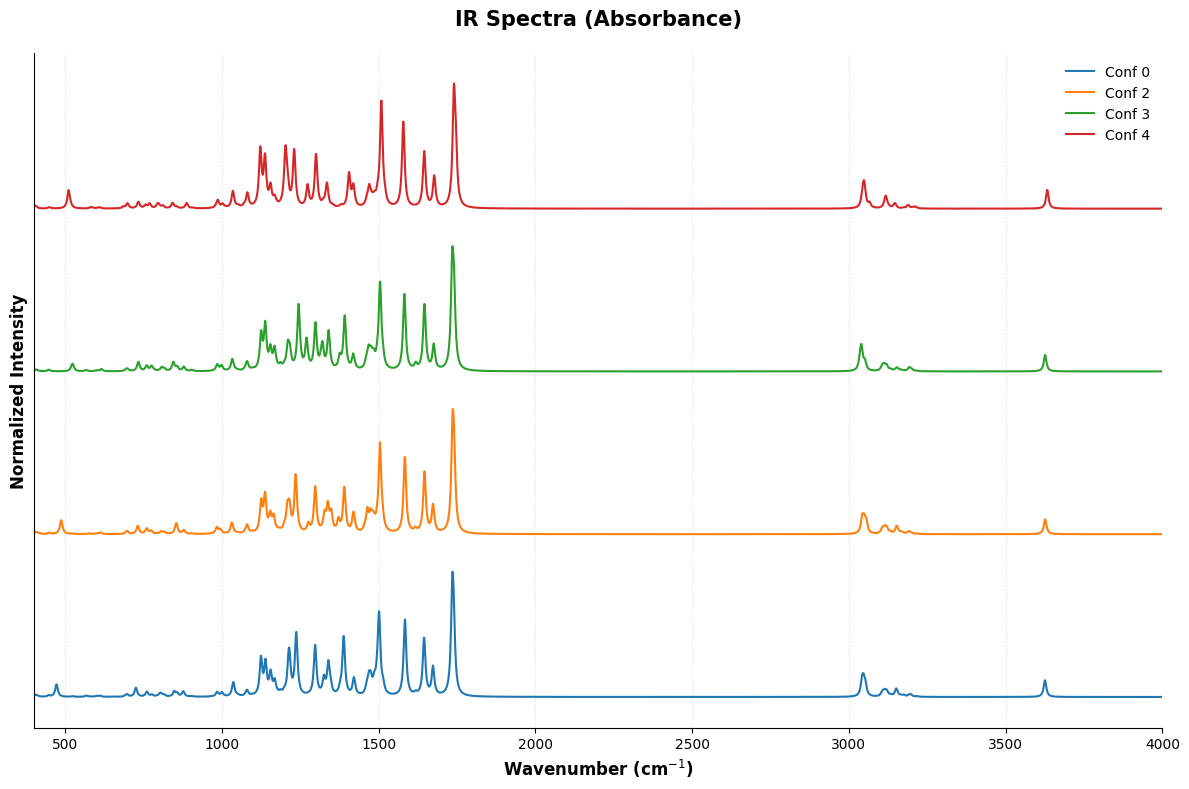

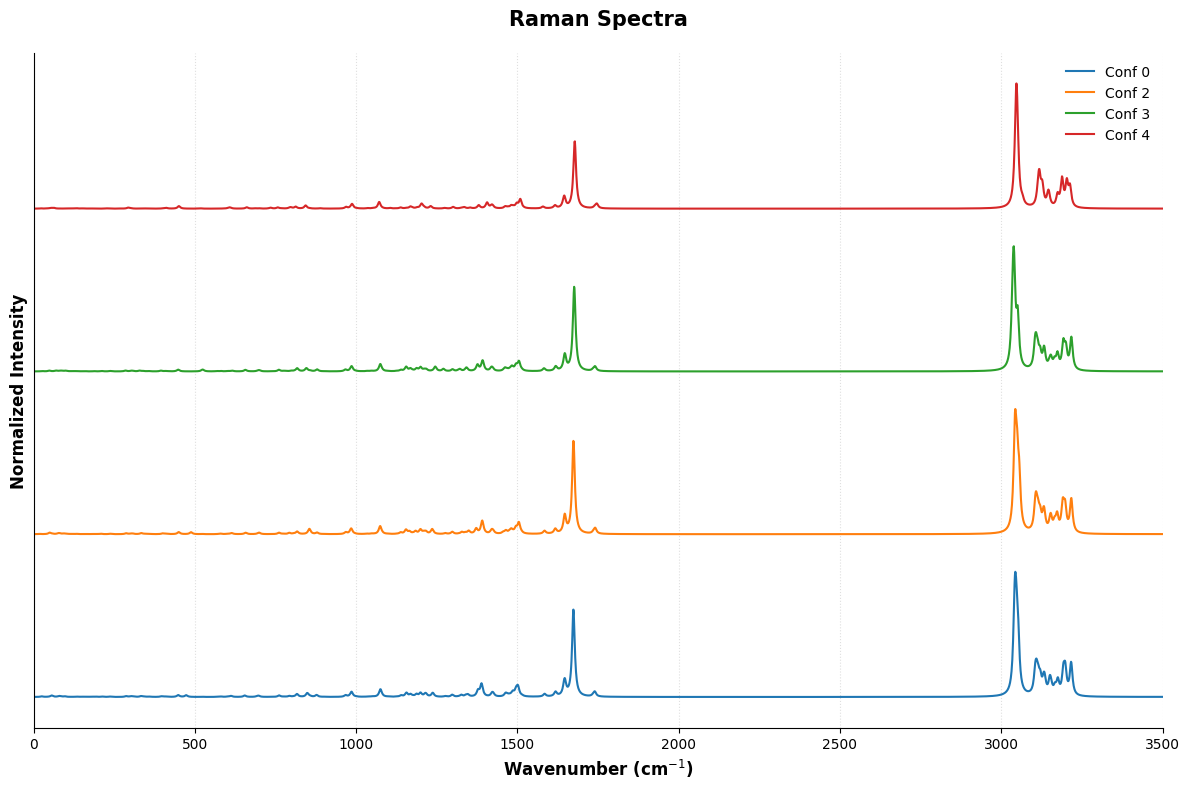

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re


# Format: "Path_to_CSV": "Legend Label"
IR_files = {
    "./Nifedipine_RamanIR/CSVFiles/Nifedipine_Opt_RamanIR_B3LYP_def2-TZVPD_D3BJ_RIJCOSX_defgrid3_GlobalMin_IRBands.csv": "Conf 0",
    "./Nifedipine_RamanIR/CSVFiles/Nifedipine_Conf2_Opt_RamanIR_B3LYP_def2-TZVPD_D3BJ_RIJCOSX_defgrid3_IRBands.csv": "Conf 2",
    "./Nifedipine_RamanIR/CSVFiles/Nifedipine_Conf3_Opt_RamanIR_B3LYP_def2-TZVPD_D3BJ_RIJCOSX_defgrid3_IRBands.csv": "Conf 3",
    "./Nifedipine_RamanIR/CSVFiles/Nifedipine_Conf4_Opt_RamanIR_B3LYP_def2-TZVPD_D3BJ_RIJCOSX_defgrid3_IRBands.csv": "Conf 4"
}

Raman_files = {
    "./Nifedipine_RamanIR/CSVFiles/Nifedipine_Opt_RamanIR_B3LYP_def2-TZVPD_D3BJ_RIJCOSX_defgrid3_GlobalMin_RamanBands.csv": "Conf 0",
    "./Nifedipine_RamanIR/CSVFiles/Nifedipine_Conf2_Opt_RamanIR_B3LYP_def2-TZVPD_D3BJ_RIJCOSX_defgrid3_RamanBands.csv": "Conf 2",
    "./Nifedipine_RamanIR/CSVFiles/Nifedipine_Conf3_Opt_RamanIR_B3LYP_def2-TZVPD_D3BJ_RIJCOSX_defgrid3_RamanBands.csv": "Conf 3",
    "./Nifedipine_RamanIR/CSVFiles/Nifedipine_Conf4_Opt_RamanIR_B3LYP_def2-TZVPD_D3BJ_RIJCOSX_defgrid3_RamanBands.csv": "Conf 4"
}


# --- Configuration & Independent Ranges ---
IR_RANGE = (400, 4000)    # Standard increasing order
RAMAN_RANGE = (0, 3500)   # Standard increasing order
FWHM = 10
OFFSET = 1.3              

def get_spectrum_curve(filepath, intensity_col, x_range, fwhm):
    # Load and clean CSV
    df = pd.read_csv(filepath, sep='\t')
    df.columns = df.columns.str.strip()
    
    # Identify freq and intensity columns
    f_vals = pd.to_numeric(df['freq(cm-1)'], errors='coerce')
    i_vals = pd.to_numeric(df[intensity_col], errors='coerce')
    
    mask = (f_vals > 0) & (i_vals.notnull())
    f_filtered = f_vals[mask].values
    i_filtered = i_vals[mask].values

    y_curve = np.zeros_like(x_range)
    gamma_sq = (0.5 * fwhm)**2
    pre = (0.5 * fwhm) / np.pi
    
    # Generate Lorentzian peaks
    for f, i in zip(f_filtered, i_filtered):
        y_curve += i * (pre / ((x_range - f)**2 + gamma_sq))
    return y_curve

def plot_vibrations_csv(file_dict, intensity_col, title, x_bounds):
    """
    Plots stacked spectra with peaks UP and X-axis increasing to the right.
    """
    plt.figure(figsize=(12, 8))
    ax = plt.gca()
    
    # Standard linear X-axis (low to high)
    x_axis = np.linspace(x_bounds[0], x_bounds[1], 3000)
    
    for i, (path, label) in enumerate(file_dict.items()):
        if not os.path.exists(path):
            print(f"File not found: {path}")
            continue
        
        y = get_spectrum_curve(path, intensity_col, x_axis, FWHM)
        
        if np.max(y) > 0:
            y_norm = y / np.max(y)
            baseline = i * OFFSET  # Peaks grow UP from the baseline
            
            plt.plot(x_axis, y_norm + baseline, label=label, lw=1.5)

    # Aesthetic Polish
    plt.title(title, fontsize=15, fontweight='bold', pad=20)
    plt.xlabel("Wavenumber (cm$^{-1}$)", fontsize=12, fontweight='bold')
    plt.ylabel("Normalized Intensity", fontsize=12, fontweight='bold')
    
    # Standard x-axis: no inversion
    plt.xlim(x_bounds[0], x_bounds[1])
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.yticks([])
    plt.legend(loc='upper right', frameon=False)
    plt.grid(axis='x', linestyle=':', alpha=0.4)
    plt.tight_layout()
    plt.show()



plot_vibrations_csv(IR_files, 'Int', "IR Spectra (Absorbance)", IR_RANGE)
plot_vibrations_csv(Raman_files, 'Activity', "Raman Spectra", RAMAN_RANGE)


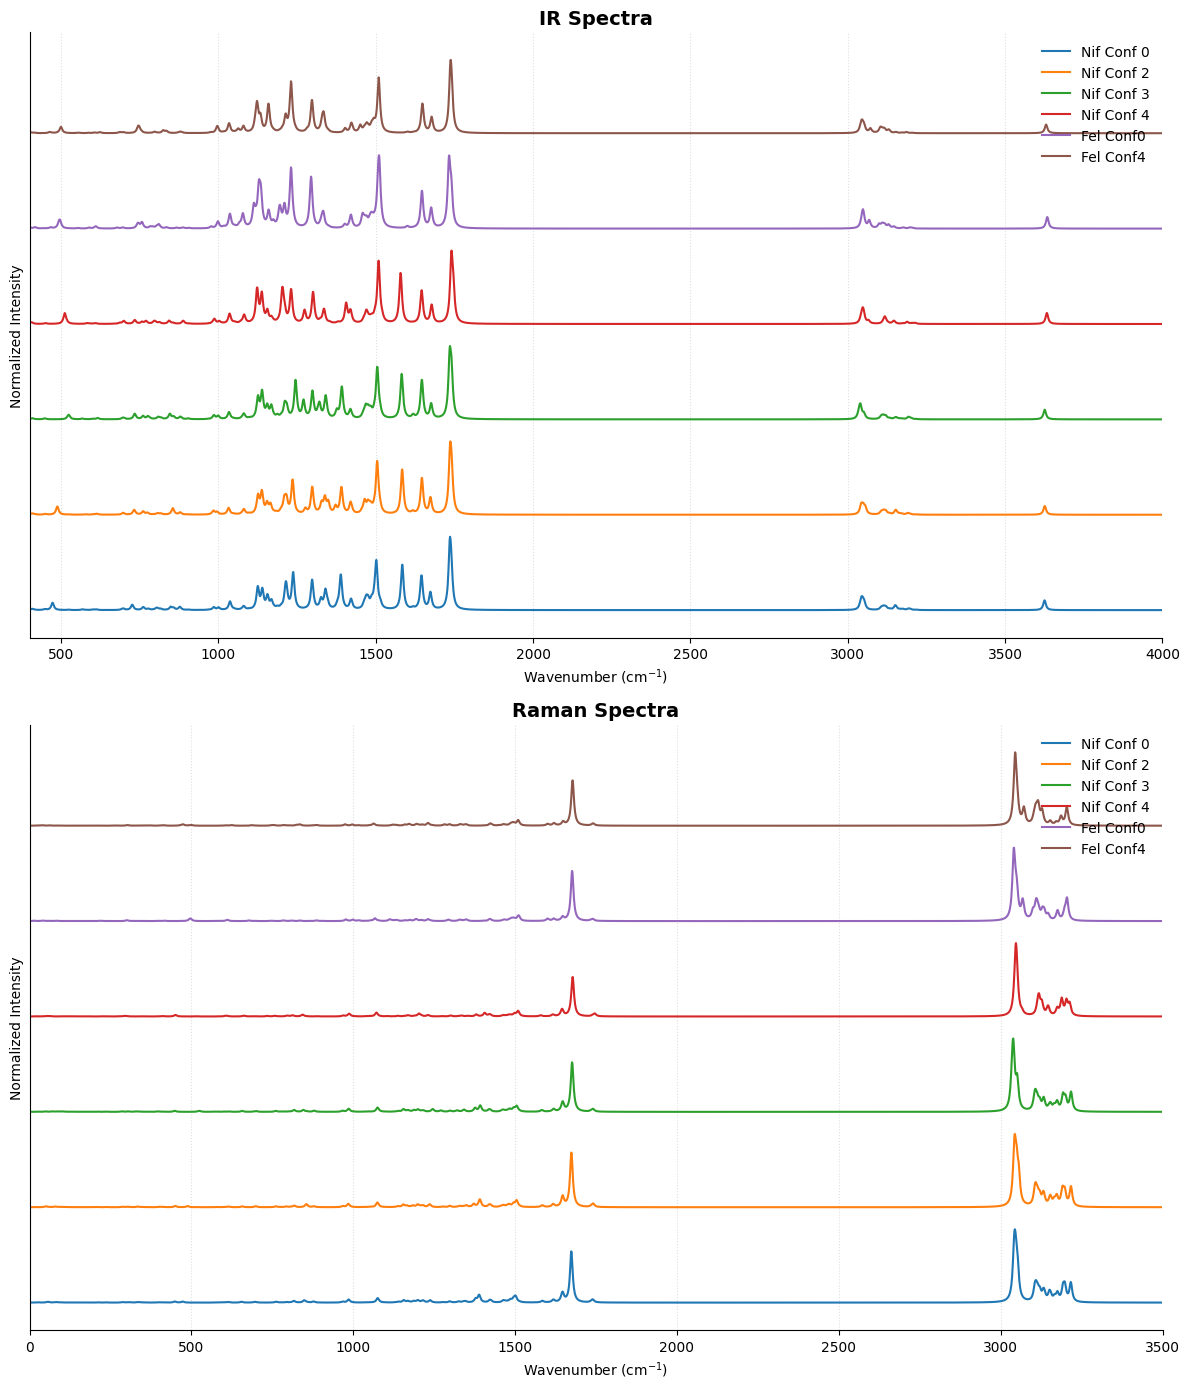

In [11]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re

def plot_orca_vibrations(file_input, ir_range=(400, 4000), raman_range=(0, 3500), 
                         fwhm=10, offset=1.3, export_csv=False):
    """
    Standalone function to parse ORCA .out files and plot stacked IR/Raman spectra.
    
    Args:
        file_input (list or dict): List of .out files OR {path: label} dictionary.
        export_csv (bool): If True, saves Band.csv files to the folder.
        Note: IR is now Absorbance (Up) and X-axis is standard (Increasing Right).
    """
    
    if isinstance(file_input, list):
        file_dict = {f: os.path.splitext(os.path.basename(f))[0].replace('_', ' ') for f in file_input}
    else:
        file_dict = file_input

    def parse_orca_out(filepath):
        ir_list, raman_list = [], []
        if not os.path.exists(filepath):
            return None, None
            
        with open(filepath, 'r') as f:
            lines = f.readlines()

        for idx, line in enumerate(lines):
            # --- Parse IR SECTION ---
            if "IR SPECTRUM" in line:
                for sub_line in lines[idx+1:]:
                    if ":" in sub_line and re.search(r'\d+:', sub_line):
                        clean = sub_line.replace(':', ' ').replace('(', ' ').replace(')', ' ')
                        parts = clean.split()
                        if len(parts) >= 8:
                            ir_list.append(parts[:8])
                    elif ("----------" in sub_line and ":" not in sub_line) or not sub_line.strip():
                        if ir_list: break

            # --- Parse RAMAN SECTION ---
            if "RAMAN SPECTRUM" in line:
                for sub_line in lines[idx+1:]:
                    if ":" in sub_line and re.search(r'\d+:', sub_line):
                        parts = sub_line.replace(':', ' ').split()
                        if len(parts) >= 4:
                            raman_list.append(parts[:4])
                    elif ("----------" in sub_line and ":" not in sub_line) or not sub_line.strip():
                        if raman_list: break
        
        return ir_list, raman_list

    # --- Initialize Plot ---
    fig, (ax_ir, ax_raman) = plt.subplots(2, 1, figsize=(12, 14))

    for i, (path, label) in enumerate(file_dict.items()):
        ir_raw, raman_raw = parse_orca_out(path)
        if ir_raw is None:
            continue
        
        base_name = os.path.splitext(path)[0]

        if export_csv:
            if ir_raw:
                with open(f"{base_name}_IRBands.csv", 'w') as f:
                    f.write("Mode\tfreq(cm-1)\teps\tInt\tT**2\tTX\tTY\tTZ\n")
                    f.write("\n".join(["\t".join(row) for row in ir_raw]))
            if raman_raw:
                with open(f"{base_name}_RamanBands.csv", 'w') as f:
                    f.write("Mode\tfreq(cm-1)\tActivity\tDepolarization\n")
                    f.write("\n".join(["\t".join(row) for row in raman_raw]))

        gamma_sq = (0.5 * fwhm)**2
        pre = (0.5 * fwhm) / np.pi

        # --- Generate IR Curve (Absorbance Mode - PEAKS UP) ---
        if ir_raw:
            data = np.array(ir_raw, dtype=float)
            x_ir = np.linspace(ir_range[0], ir_range[1], 3000)
            y_curve = np.zeros_like(x_ir)
            for f, intensity in zip(data[:, 1], data[:, 3]):
                if f > 0: y_curve += intensity * (pre / ((x_ir - f)**2 + gamma_sq))
            
            y_norm = y_curve / np.max(y_curve)
            baseline = i * offset  # Baseline at bottom
            ax_ir.plot(x_ir, y_norm + baseline, label=label, lw=1.5)

        # --- Generate Raman Curve (Activity Mode - PEAKS UP) ---
        if raman_raw:
            data = np.array(raman_raw, dtype=float)
            x_raman = np.linspace(raman_range[0], raman_range[1], 3000)
            y_curve = np.zeros_like(x_raman)
            for f, activity in zip(data[:, 1], data[:, 2]):
                if f > 0: y_curve += activity * (pre / ((x_raman - f)**2 + gamma_sq))
            
            y_norm = y_curve / np.max(y_curve)
            baseline = i * offset
            ax_raman.plot(x_raman, y_norm + baseline, label=label, lw=1.5)

    # --- Final Formatting (Standard X-Axis: Increasing Right) ---
    ax_ir.set_title("IR Spectra", fontweight='bold', fontsize=14)
    ax_ir.set_xlim(ir_range[0], ir_range[1]) # Standard increasing
    ax_ir.set_ylabel("Normalized Intensity")

    ax_raman.set_title("Raman Spectra", fontweight='bold', fontsize=14)
    ax_raman.set_xlim(raman_range[0], raman_range[1]) # Standard increasing
    ax_raman.set_ylabel("Normalized Intensity")

    for ax in [ax_ir, ax_raman]:
        ax.set_xlabel("Wavenumber (cm$^{-1}$)")
        ax.set_yticks([])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='x', linestyle=':', alpha=0.4)
        ax.legend(frameon=False, loc='upper right')

    plt.tight_layout()
    plt.show()


orca_files = {
    "./Nifedipine_RamanIR/OutputFiles/Nifedipine_Opt_RamanIR_B3LYP_def2-TZVPD_D3BJ_RIJCOSX_defgrid3_GlobalMin.out": "Nif Conf 0",
    "./Nifedipine_RamanIR/OutputFiles/Nifedipine_Conf2_Opt_RamanIR_B3LYP_def2-TZVPD_D3BJ_RIJCOSX_defgrid3.out": "Nif Conf 2",
    "./Nifedipine_RamanIR/OutputFiles/Nifedipine_Conf3_Opt_RamanIR_B3LYP_def2-TZVPD_D3BJ_RIJCOSX_defgrid3.out": "Nif Conf 3",
    "./Nifedipine_RamanIR/OutputFiles/Nifedipine_Conf4_Opt_RamanIR_B3LYP_def2-TZVPD_D3BJ_RIJCOSX_defgrid3.out": "Nif Conf 4",
    "./Felodipine_RamanIR/OutputFiles/Felodipine_GlobalMin_Conf0_RamanIR_Opt_B3LYP_def2-TZVPD_D3BJ_RIJCOSX_defgrid3.out": "Fel Conf0",
    "./Felodipine_RamanIR/OutputFiles/Felodipine_Conf4_RamanIR_Opt_B3LYP_def2-TZVPD_D3BJ_RIJCOSX_defgrid3.out": "Fel Conf4"
}

plot_orca_vibrations(orca_files, export_csv=False)